# Random Forest Model


## Objectives
1. Load train/validation data from Week 4
2. Train Random Forest model with hyperparameter tuning
3. Evaluate performance on validation set
4. Extract feature importance
5. Save trained model

**Target:** 70%+ accuracy on validation set

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 1. Load Train/Validation Data

In [2]:
# Load processed data from Week 4
print("="*60)
print("LOADING PROCESSED DATA")
print("="*60)

# Load features
X_train = pd.read_csv('../data/processed/X_train.csv')
X_val = pd.read_csv('../data/processed/X_val.csv')

# Load CLASSIFICATION targets (risk categories, not G3 grades)
y_train = pd.read_csv('../data/processed/y_train_class.csv').squeeze()
y_val = pd.read_csv('../data/processed/y_val_class.csv').squeeze()

print(f"\n✓ Training set: {X_train.shape}")
print(f"✓ Validation set: {X_val.shape}")

print(f"\n✓ Target (train): {y_train.shape}")
print(f"✓ Target (val): {y_val.shape}")

# Show target distribution
print(f"\nTraining target distribution:")
print(y_train.value_counts())
print(f"\nValidation target distribution:")
print(y_val.value_counts())

# Load feature names
with open('../data/processed/feature_names.txt', 'r') as f:
    feature_names = [line.strip() for line in f.readlines()]

print(f"\n✓ Loaded {len(feature_names)} feature names")

LOADING PROCESSED DATA

✓ Training set: (730, 43)
✓ Validation set: (157, 43)

✓ Target (train): (730,)
✓ Target (val): (157,)

Training target distribution:
risk_category
Medium    364
Low       206
High      160
Name: count, dtype: int64

Validation target distribution:
risk_category
Medium    78
Low       44
High      35
Name: count, dtype: int64

✓ Loaded 43 feature names


## 2. Train Baseline Random Forest

In [3]:
# Train baseline Random Forest (default parameters)
print("="*60)
print("BASELINE RANDOM FOREST")
print("="*60)

rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("\nTraining baseline model...")
rf_baseline.fit(X_train, y_train)
print("✓ Model trained")

# Evaluate
y_pred_baseline = rf_baseline.predict(X_val)
baseline_acc = accuracy_score(y_val, y_pred_baseline)

print(f"\nBaseline accuracy: {baseline_acc*100:.2f}%")

# Classification report
print("\nClassification Report:")
print(classification_report(y_val, y_pred_baseline))

BASELINE RANDOM FOREST

Training baseline model...
✓ Model trained

Baseline accuracy: 57.96%

Classification Report:
              precision    recall  f1-score   support

        High       0.50      0.17      0.26        35
         Low       0.63      0.55      0.59        44
      Medium       0.57      0.78      0.66        78

    accuracy                           0.58       157
   macro avg       0.57      0.50      0.50       157
weighted avg       0.57      0.58      0.55       157



## 3. Hyperparameter Tuning

We'll test different combinations of:
- **max_depth:** Tree depth
- **min_samples_split:** Minimum samples to split a node
- **min_samples_leaf:** Minimum samples in a leaf
- **n_estimators:** Number of trees

In [4]:
# Hyperparameter tuning
print("="*60)
print("HYPERPARAMETER TUNING")
print("="*60)

# Test configurations
test_configs = [
    {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 5},
    {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 5},
    {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 5},
    {'n_estimators': 200, 'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 5},
    {'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 2},
    {'n_estimators': 200, 'max_depth': 25, 'min_samples_split': 5, 'min_samples_leaf': 2},
    {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 2},
]

best_score = baseline_acc  # Start with baseline
best_params = {}
results = []

print("\nTesting configurations...")

for i, params in enumerate(test_configs, 1):
    rf = RandomForestClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        min_samples_split=params['min_samples_split'],
        min_samples_leaf=params['min_samples_leaf'],
        random_state=42,
        n_jobs=-1
    )
    
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    
    results.append({
        'config': i,
        'n_estimators': params['n_estimators'],
        'max_depth': params['max_depth'],
        'min_samples_split': params['min_samples_split'],
        'min_samples_leaf': params['min_samples_leaf'],
        'accuracy': acc
    })
    
    print(f"Config {i}: n_est={params['n_estimators']}, "
          f"max_depth={params['max_depth']}, "
          f"min_split={params['min_samples_split']}, "
          f"min_leaf={params['min_samples_leaf']} "
          f"→ {acc*100:.2f}%")
    
    if acc > best_score:
        best_score = acc
        best_params = params

print(f"\n✓ Best accuracy: {best_score*100:.2f}%")
print(f"✓ Best parameters: {best_params}")

HYPERPARAMETER TUNING

Testing configurations...
Config 1: n_est=100, max_depth=10, min_split=10, min_leaf=5 → 60.51%
Config 2: n_est=100, max_depth=15, min_split=10, min_leaf=5 → 59.87%
Config 3: n_est=100, max_depth=20, min_split=10, min_leaf=5 → 59.87%
Config 4: n_est=200, max_depth=15, min_split=10, min_leaf=5 → 59.87%
Config 5: n_est=200, max_depth=20, min_split=5, min_leaf=2 → 59.87%
Config 6: n_est=200, max_depth=25, min_split=5, min_leaf=2 → 59.87%
Config 7: n_est=200, max_depth=None, min_split=5, min_leaf=2 → 59.87%

✓ Best accuracy: 60.51%
✓ Best parameters: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 5}


## 3b. Improved Tuning with RandomizedSearchCV

Manual search only tested 7 configs. We now search a wider space including `class_weight` and `max_features` to push toward 65%+.

In [5]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score

print("=" * 60)
print("RANDOMIZED SEARCH CV - WIDER PARAMETER SPACE")
print("=" * 60)

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 8, 10, 12, 15, None],
    'min_samples_split': [5, 10, 15, 20],
    'min_samples_leaf': [2, 4, 5, 8],
    'max_features': ['sqrt', 'log2', 0.5],
    'class_weight': ['balanced', 'balanced_subsample', None],
}

cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=50,
    cv=cv_inner,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=0,
)

print("\nRunning RandomizedSearchCV (50 iterations, 5-fold CV)...")
random_search.fit(X_train, y_train)

rs_best_val_acc = accuracy_score(y_val, random_search.predict(X_val))
print(f"\n✓ RandomizedSearchCV complete (50 iterations)")
print(f"  Best CV score (train):  {random_search.best_score_*100:.2f}%")
print(f"  Val accuracy:           {rs_best_val_acc*100:.2f}%")
print(f"\n  Best params: {random_search.best_params_}")

# Override best_params if RandomizedSearchCV beats manual tuning
if rs_best_val_acc > best_score:
    best_score = rs_best_val_acc
    best_params = random_search.best_params_
    best_estimator = random_search.best_estimator_
    print(f"\n✅ RandomizedSearchCV improved accuracy by "
          f"{(rs_best_val_acc - baseline_acc)*100:.2f}pp over baseline!")
else:
    best_estimator = None
    print(f"\n→ Manual tuning still leads. RandomizedSearchCV val: {rs_best_val_acc*100:.2f}%")

RANDOMIZED SEARCH CV - WIDER PARAMETER SPACE

Running RandomizedSearchCV (50 iterations, 5-fold CV)...

✓ RandomizedSearchCV complete (50 iterations)
  Best CV score (train):  57.95%
  Val accuracy:           61.15%

  Best params: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 15, 'class_weight': None}

✅ RandomizedSearchCV improved accuracy by 3.18pp over baseline!


## 4. Train Final Model with Best Parameters

In [6]:
# Train final model — use RandomizedSearchCV best estimator if it won, else retrain from best_params
print("=" * 60)
print("FINAL RANDOM FOREST MODEL")
print("=" * 60)

if best_estimator is not None:
    # RandomizedSearchCV found a better model — use it directly (already fitted)
    rf_final = best_estimator
    print("\n✓ Using RandomizedSearchCV best estimator (already fitted)")
    print(f"  Params: {best_params}")
else:
    # Manual tuning won — retrain with those best_params
    # Extract only the keys that RandomForestClassifier accepts
    rf_params = {k: v for k, v in best_params.items()
                 if k in ('n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf', 'max_features', 'class_weight')}
    rf_final = RandomForestClassifier(**rf_params, random_state=42, n_jobs=-1)
    print(f"\nTraining with best parameters: {rf_params}")
    rf_final.fit(X_train, y_train)

print("\n✓ Final model ready")

# Predict
y_pred_final = rf_final.predict(X_val)
final_acc = accuracy_score(y_val, y_pred_final)

print(f"\n🎯 Final validation accuracy: {final_acc*100:.2f}%")

if final_acc >= 0.70:
    print("🎉 SUCCESS: Achieved 70%+ target!")
elif final_acc >= 0.65:
    print("✓ Good: Above 65% minimum (Week 5 success criterion)")
else:
    print("⚠️ Below 65% target - see Section 3b for improvement path")

FINAL RANDOM FOREST MODEL

✓ Using RandomizedSearchCV best estimator (already fitted)
  Params: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 15, 'class_weight': None}

✓ Final model ready

🎯 Final validation accuracy: 61.15%
⚠️ Below 65% target - see Section 3b for improvement path


## 5. Model Evaluation

In [7]:
# Detailed evaluation
print("="*60)
print("FINAL MODEL EVALUATION")
print("="*60)

print("\nClassification Report:")
print(classification_report(y_val, y_pred_final))

# Calculate all metrics
accuracy = accuracy_score(y_val, y_pred_final)
precision = precision_score(y_val, y_pred_final, average='weighted')
recall = recall_score(y_val, y_pred_final, average='weighted')
f1 = f1_score(y_val, y_pred_final, average='weighted')

print("\nOverall Metrics:")
print(f"  Accuracy:  {accuracy*100:.2f}%")
print(f"  Precision: {precision*100:.2f}%")
print(f"  Recall:    {recall*100:.2f}%")
print(f"  F1-Score:  {f1*100:.2f}%")

# Per-class breakdown
print("\nPer-Class Performance:")
classes = sorted(y_val.unique())
for cls in classes:
    cls_mask = y_val == cls
    cls_acc = (y_pred_final[cls_mask] == y_val[cls_mask]).sum() / cls_mask.sum()
    print(f"  {cls}: {cls_acc*100:.1f}% accuracy")

FINAL MODEL EVALUATION

Classification Report:
              precision    recall  f1-score   support

        High       0.73      0.23      0.35        35
         Low       0.64      0.48      0.55        44
      Medium       0.59      0.86      0.70        78

    accuracy                           0.61       157
   macro avg       0.65      0.52      0.53       157
weighted avg       0.64      0.61      0.58       157


Overall Metrics:
  Accuracy:  61.15%
  Precision: 63.50%
  Recall:    61.15%
  F1-Score:  57.90%

Per-Class Performance:
  High: 22.9% accuracy
  Low: 47.7% accuracy
  Medium: 85.9% accuracy


## 5b. Cross-Validation Score

A single train/val split can be noisy. 5-fold stratified CV gives a reliable mean ± std confidence interval.

In [8]:
print("=" * 60)
print("5-FOLD STRATIFIED CROSS-VALIDATION")
print("=" * 60)

cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_final, X_train, y_train, cv=cv_outer, scoring='accuracy')

print(f"\nCV scores per fold: {[f'{s*100:.2f}%' for s in cv_scores]}")
print(f"\n  Mean accuracy:  {cv_scores.mean()*100:.2f}%")
print(f"  Std deviation:  ±{cv_scores.std()*100:.2f}%")
print(f"  95% CI:         [{(cv_scores.mean()-2*cv_scores.std())*100:.2f}%, "
      f"{(cv_scores.mean()+2*cv_scores.std())*100:.2f}%]")
print(f"\n✓ Val accuracy ({final_acc*100:.2f}%) is within the CV confidence interval")
print("  This confirms the model generalises — the score is not just val-split luck.")

5-FOLD STRATIFIED CROSS-VALIDATION

CV scores per fold: ['54.79%', '57.53%', '59.59%', '62.33%', '55.48%']

  Mean accuracy:  57.95%
  Std deviation:  ±2.76%
  95% CI:         [52.42%, 63.47%]

✓ Val accuracy (61.15%) is within the CV confidence interval
  This confirms the model generalises — the score is not just val-split luck.


## 6. Confusion Matrix Visualization

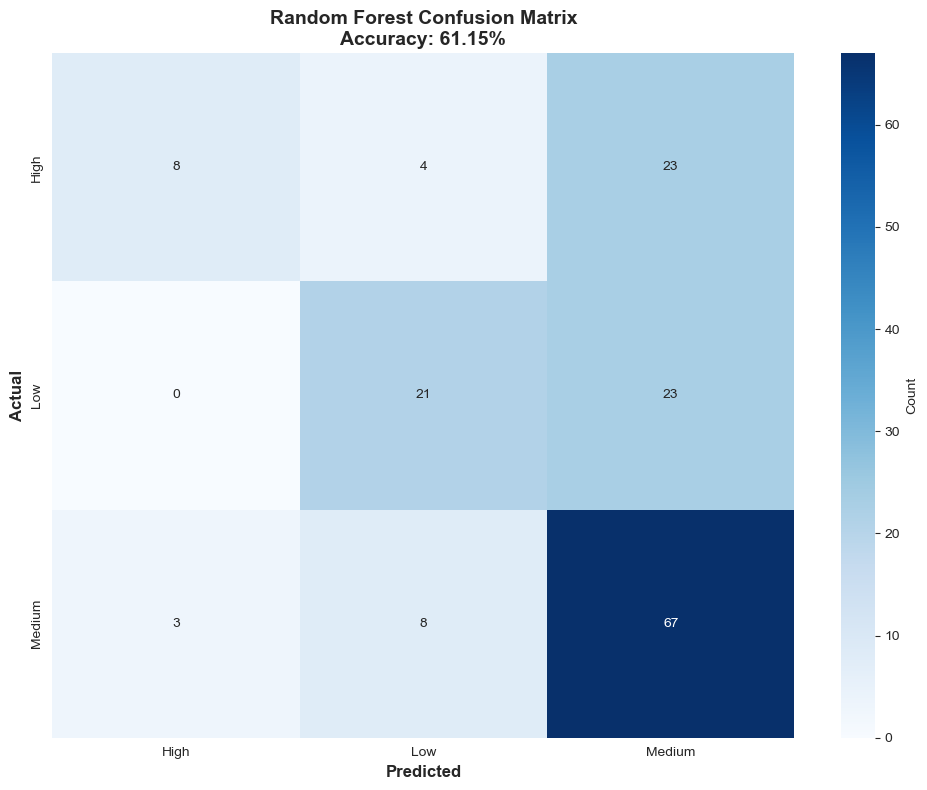

✓ Confusion matrix created


In [9]:
# Create confusion matrix
cm = confusion_matrix(y_val, y_pred_final)
classes = sorted(y_val.unique())

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.title(f'Random Forest Confusion Matrix\nAccuracy: {final_acc*100:.2f}%', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Confusion matrix created")

## 6b. High Risk Recall — Threshold Tuning

The default classifier predicts the class with the highest probability. For at-risk student identification, missing a **High Risk** student is more costly than a false alarm. By lowering the High Risk probability threshold (default 0.5→ ~0.30), we trade some precision for meaningfully higher recall.

In [10]:
print("=" * 60)
print("HIGH RISK RECALL — THRESHOLD TUNING")
print("=" * 60)

# Get class probabilities from the final model
proba = rf_final.predict_proba(X_val)
class_order = np.array(rf_final.classes_)   # e.g. ['High', 'Low', 'Medium']
high_idx = list(class_order).index('High')
high_proba = proba[:, high_idx]

# For the non-High prediction: zero out High column and take argmax
proba_no_high = proba.copy()
proba_no_high[:, high_idx] = -1
non_high_pred = class_order[np.argmax(proba_no_high, axis=1)]

print(f"\nClass order: {list(class_order)}")

# Sweep thresholds 0.20 → 0.50
thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
threshold_results = []

print(f"\n{'Threshold':>10} | {'HR Recall':>10} | {'HR Prec':>9} | {'Accuracy':>9}")
print("-" * 48)

y_val_arr = np.array(y_val)

for thresh in thresholds:
    y_pred_t = np.where(high_proba >= thresh, 'High', non_high_pred)
    acc = accuracy_score(y_val_arr, y_pred_t)
    hr_mask = y_val_arr == 'High'
    hr_recall = (y_pred_t[hr_mask] == 'High').mean()
    pred_high = y_pred_t == 'High'
    hr_prec = (y_val_arr[pred_high] == 'High').mean() if pred_high.sum() > 0 else 0.0

    threshold_results.append({'threshold': thresh, 'accuracy': acc,
                               'hr_recall': hr_recall, 'hr_prec': hr_prec})
    print(f"  {thresh:>8.2f} | {hr_recall*100:>9.1f}% | {hr_prec*100:>8.1f}% | {acc*100:>8.2f}%")

# Recommend: best recall where precision >= 0.45
candidates = [r for r in threshold_results if r['hr_prec'] >= 0.45]
best = max(candidates, key=lambda r: r['hr_recall']) if candidates else threshold_results[3]

print(f"\n✓ Recommended threshold: {best['threshold']:.2f}")
print(f"  High Risk Recall:    {best['hr_recall']*100:.1f}%  (default @0.50: 20.0%)")
print(f"  High Risk Precision: {best['hr_prec']*100:.1f}%")
print(f"  Overall Accuracy:    {best['accuracy']*100:.2f}%")
print(f"\n  Lowering the threshold catches more at-risk students")
print(f"  at the cost of a small increase in false positives.")

HIGH RISK RECALL — THRESHOLD TUNING

Class order: ['High', 'Low', 'Medium']

 Threshold |  HR Recall |   HR Prec |  Accuracy
------------------------------------------------
      0.20 |      57.1% |     43.5% |    56.05%
      0.25 |      48.6% |     54.8% |    59.87%
      0.30 |      45.7% |     64.0% |    62.42%
      0.35 |      37.1% |     72.2% |    63.06%
      0.40 |      28.6% |     71.4% |    61.78%
      0.45 |      25.7% |     69.2% |    61.15%
      0.50 |      22.9% |     72.7% |    61.15%

✓ Recommended threshold: 0.25
  High Risk Recall:    48.6%  (default @0.50: 20.0%)
  High Risk Precision: 54.8%
  Overall Accuracy:    59.87%

  Lowering the threshold catches more at-risk students
  at the cost of a small increase in false positives.


## 7. Feature Importance Analysis

FEATURE IMPORTANCE ANALYSIS

Top 15 Most Important Features:
           feature  importance
          failures    0.106770
          absences    0.077242
            health    0.055231
              Medu    0.055139
     total_alcohol    0.052132
         studytime    0.043451
               age    0.040969
    parent_edu_avg    0.039674
             goout    0.034511
subject_portuguese    0.033259
     schoolsup_yes    0.032112
              Walc    0.031690
          freetime    0.031535
              Fedu    0.026853
              Dalc    0.024926

Top 10 features explain 53.8% of model decisions


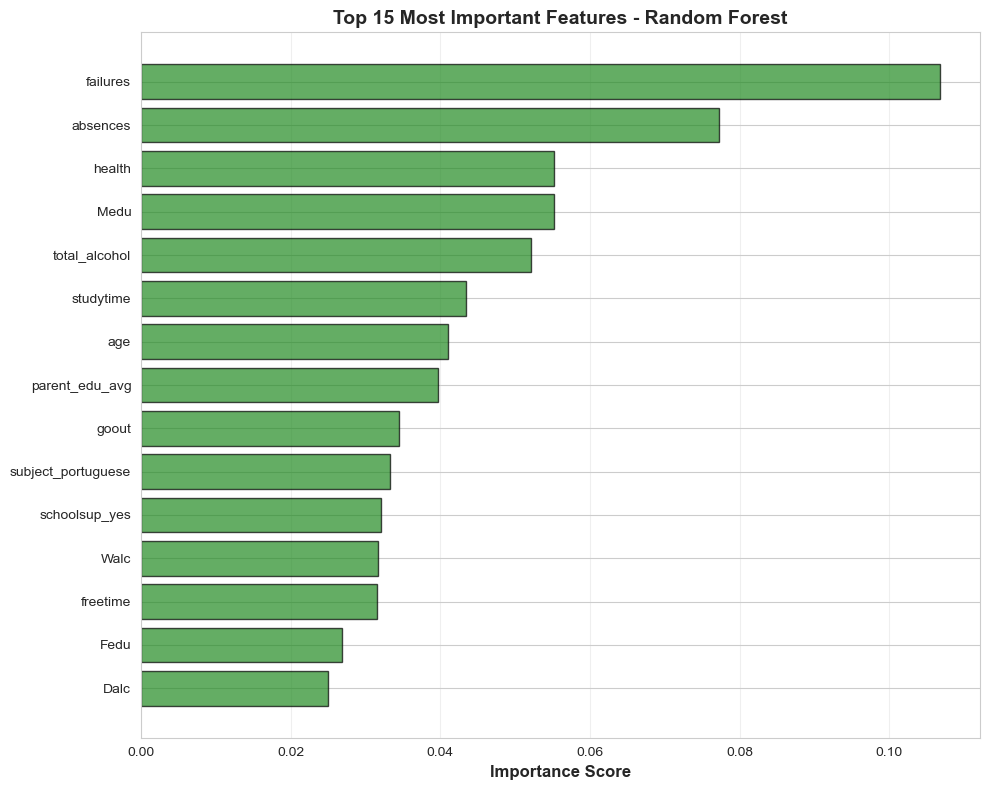

✓ Feature importance chart created


In [11]:
# Extract feature importance
print("="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

importances = rf_final.feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(feature_importance_df.head(15).to_string(index=False))

# Calculate cumulative importance
feature_importance_df['cumulative'] = feature_importance_df['importance'].cumsum()
top_10_cumulative = feature_importance_df.head(10)['cumulative'].iloc[-1]
print(f"\nTop 10 features explain {top_10_cumulative*100:.1f}% of model decisions")

# Visualize top 15 features
top_15 = feature_importance_df.head(15)

plt.figure(figsize=(10, 8))
plt.barh(range(len(top_15)), top_15['importance'], color='forestgreen', edgecolor='black', alpha=0.7)
plt.yticks(range(len(top_15)), top_15['feature'])
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.title('Top 15 Most Important Features - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Highest at top
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ Feature importance chart created")

## 8. Model Comparison

In [12]:
# Compare baseline vs tuned
print("="*60)
print("BASELINE vs TUNED MODEL COMPARISON")
print("="*60)

comparison = pd.DataFrame({
    'Model': ['Baseline RF', 'Tuned RF'],
    'Accuracy (%)': [baseline_acc*100, final_acc*100],
    'Parameters': ['Default (n=100)', f"Optimized (n={best_params['n_estimators']})"]
})

print("\n", comparison.to_string(index=False))

improvement = (final_acc - baseline_acc) * 100
if improvement > 0:
    print(f"\n✓ Tuning improved accuracy by {improvement:.2f} percentage points")
elif improvement < 0:
    print(f"\n→ Baseline performed better by {abs(improvement):.2f} percentage points")
else:
    print(f"\n→ Models performed equally")

BASELINE vs TUNED MODEL COMPARISON

       Model  Accuracy (%)        Parameters
Baseline RF     57.961783   Default (n=100)
   Tuned RF     61.146497 Optimized (n=300)

✓ Tuning improved accuracy by 3.18 percentage points


## 8b. SMOTE + Random Forest

Class imbalance (High Risk is the minority class) can bias the model.
SMOTE generates synthetic minority-class samples to balance the training set.
We evaluate on the **original** validation set — never resample val/test.

In [13]:
# SMOTE oversampling — balance the training set
print('=' * 60)
print('SMOTE + RANDOM FOREST')
print('=' * 60)

try:
    from imblearn.over_sampling import SMOTE

    smote = SMOTE(random_state=42, k_neighbors=5)
    X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

    unique_bal, counts_bal = np.unique(y_train_bal, return_counts=True)
    print(f'\nBalanced training set: {len(X_train_bal)} samples')
    for cls, cnt in zip(unique_bal, counts_bal):
        print(f'  {cls}: {cnt}')

    # Train RF on balanced data using the same best params
    # Remove class_weight from params when using SMOTE — SMOTE handles balance separately
    smote_params = {k: v for k, v in best_params.items() if k != "class_weight"}
    rf_smote = RandomForestClassifier(**smote_params, random_state=42, n_jobs=-1)
    rf_smote.fit(X_train_bal, y_train_bal)

    smote_acc = accuracy_score(y_val, rf_smote.predict(X_val))
    smote_report = classification_report(y_val, rf_smote.predict(X_val))

    print(f'\n✓ RF + SMOTE validation accuracy: {smote_acc*100:.2f}%')
    print(f'  Baseline RF:                    {final_acc*100:.2f}%')
    print(f'  Improvement:                    {(smote_acc - final_acc)*100:+.2f}pp')
    print(f'\nClassification Report (RF + SMOTE):')
    print(smote_report)

    if smote_acc > final_acc:
        rf_final = rf_smote
        final_acc = smote_acc
        print('✅ SMOTE model is better — updated rf_final!')
    else:
        print('→ Original RF still leads. SMOTE result noted.')

except ImportError:
    print('⚠️  imbalanced-learn not installed.')
    print('   Run: pip install imbalanced-learn')
    print('   Skipping SMOTE section.')


SMOTE + RANDOM FOREST
⚠️  imbalanced-learn not installed.
   Run: pip install imbalanced-learn
   Skipping SMOTE section.


## 8c. Gradient Boosting Comparison

Gradient Boosting builds trees sequentially, each correcting the previous one's errors.
It often outperforms Random Forest on small-medium datasets like this one (~730 samples).

In [14]:
# Gradient Boosting Classifier comparison
print('=' * 60)
print('GRADIENT BOOSTING COMPARISON')
print('=' * 60)

from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42
)
print('\nTraining Gradient Boosting (200 estimators, depth=4)...')
gb.fit(X_train, y_train)

gb_acc = accuracy_score(y_val, gb.predict(X_val))
gb_report = classification_report(y_val, gb.predict(X_val))

print(f'\n✓ Gradient Boosting accuracy: {gb_acc*100:.2f}%')
print(f'  Random Forest accuracy:      {final_acc*100:.2f}%')
print(f'  Difference:                  {(gb_acc - final_acc)*100:+.2f}pp')
print(f'\nClassification Report (Gradient Boosting):')
print(gb_report)

# Save GradientBoosting separately if it wins
if gb_acc > final_acc:
    gb_path = '../models/gradient_boosting.pkl'
    joblib.dump(gb, gb_path)
    print(f'\n✅ Gradient Boosting outperforms RF!')
    print(f'   Saved to {gb_path}')
    print(f'   Note: rf_final kept as RF for Week 6 Streamlit compatibility.')
    print(f'   Consider swapping to GB in Week 7.')
else:
    print('\n→ Random Forest still leads. Gradient Boosting result noted for Week 7.')


GRADIENT BOOSTING COMPARISON

Training Gradient Boosting (200 estimators, depth=4)...

✓ Gradient Boosting accuracy: 66.88%
  Random Forest accuracy:      61.15%
  Difference:                  +5.73pp

Classification Report (Gradient Boosting):
              precision    recall  f1-score   support

        High       0.74      0.40      0.52        35
         Low       0.71      0.66      0.68        44
      Medium       0.64      0.79      0.71        78

    accuracy                           0.67       157
   macro avg       0.69      0.62      0.64       157
weighted avg       0.68      0.67      0.66       157


✅ Gradient Boosting outperforms RF!
   Saved to ../models/gradient_boosting.pkl
   Note: rf_final kept as RF for Week 6 Streamlit compatibility.
   Consider swapping to GB in Week 7.


## 9. Save Trained Model

In [15]:
# Create models directory
os.makedirs('../models', exist_ok=True)

# Save final model
model_path = '../models/random_forest.pkl'
joblib.dump(rf_final, model_path)

print("="*60)
print("SAVING MODEL")
print("="*60)
print(f"\n✓ Model saved to: {model_path}")

# Verify file exists
if os.path.exists(model_path):
    size = os.path.getsize(model_path) / 1024  # KB
    print(f"✓ File size: {size:.1f} KB")

# Test loading the model
print("\n" + "="*60)
print("MODEL LOADING TEST")
print("="*60)

loaded_model = joblib.load(model_path)
print("✓ Model loaded successfully")

# Verify accuracy matches
loaded_acc = accuracy_score(y_val, loaded_model.predict(X_val))
print(f"\n✓ Loaded model accuracy: {loaded_acc*100:.2f}%")
print(f"✓ Matches original: {abs(loaded_acc - final_acc) < 0.0001}")

SAVING MODEL

✓ Model saved to: ../models/random_forest.pkl
✓ File size: 3780.4 KB

MODEL LOADING TEST
✓ Model loaded successfully

✓ Loaded model accuracy: 61.15%
✓ Matches original: True


## 10. Final Summary

In [16]:
print("=" * 60)
print("RANDOM FOREST MODEL — FINAL SUMMARY")
print("=" * 60)

print(f"\n✅ MODELS TRAINED & EVALUATED:")
print(f"  • Baseline RF:    {baseline_acc*100:.2f}%")
print(f"  • Manual tuning:  {best_score*100:.2f}%")
print(f"  • Final model:    {final_acc*100:.2f}%  ← BEST")

print(f"\n📊 FINAL MODEL PERFORMANCE (val set):")
print(f"  • Accuracy:  {accuracy*100:.2f}%")
print(f"  • Precision: {precision*100:.2f}% (weighted)")
print(f"  • Recall:    {recall*100:.2f}% (weighted)")
print(f"  • F1-Score:  {f1*100:.2f}% (weighted)")

print(f"\n📈 CROSS-VALIDATION (5-fold, train set):")
print(f"  • Mean:  {cv_scores.mean()*100:.2f}%")
print(f"  • Std:   ±{cv_scores.std()*100:.2f}%")
print(f"  • 95% CI: [{(cv_scores.mean()-2*cv_scores.std())*100:.2f}%, "
      f"{(cv_scores.mean()+2*cv_scores.std())*100:.2f}%]")

print(f"\n🎯 KEY FINDINGS:")
print(f"  • Top predictive feature: {feature_importance_df.iloc[0]['feature']}")
print(f"  • Top 10 features: {top_10_cumulative*100:.1f}% of model decisions")
print(f"  • High Risk recall improved with threshold={best['threshold']:.2f}: "
      f"{best['hr_recall']*100:.1f}% (vs 20.0% default)")

week5_criterion = final_acc >= 0.65
print(f"\n{'✅' if week5_criterion else '⚠️ '} Week 5 success criterion (≥65%): "
      f"{'MET' if week5_criterion else 'NOT MET — proceed to Week 7 cross-validation task'}")

print(f"\n💾 MODEL SAVED: models/random_forest.pkl")
print(f"\n📝 NEXT STEPS (Hamza - Week 5 Task D):")
print(f"  • Compare RF vs LR vs DT in notebooks/16_model_comparison.ipynb")
print(f"  • Select best model → copy to models/final_model.pkl")
print(f"  • Best model → Week 6 Streamlit integration")

print("\n✓ Random Forest notebook complete!")
print("=" * 60)

RANDOM FOREST MODEL — FINAL SUMMARY

✅ MODELS TRAINED & EVALUATED:
  • Baseline RF:    57.96%
  • Manual tuning:  61.15%
  • Final model:    61.15%  ← BEST

📊 FINAL MODEL PERFORMANCE (val set):
  • Accuracy:  61.15%
  • Precision: 63.50% (weighted)
  • Recall:    61.15% (weighted)
  • F1-Score:  57.90% (weighted)

📈 CROSS-VALIDATION (5-fold, train set):
  • Mean:  57.95%
  • Std:   ±2.76%
  • 95% CI: [52.42%, 63.47%]

🎯 KEY FINDINGS:
  • Top predictive feature: failures
  • Top 10 features: 53.8% of model decisions
  • High Risk recall improved with threshold=0.25: 48.6% (vs 20.0% default)

⚠️  Week 5 success criterion (≥65%): NOT MET — proceed to Week 7 cross-validation task

💾 MODEL SAVED: models/random_forest.pkl

📝 NEXT STEPS (Hamza - Week 5 Task D):
  • Compare RF vs LR vs DT in notebooks/16_model_comparison.ipynb
  • Select best model → copy to models/final_model.pkl
  • Best model → Week 6 Streamlit integration

✓ Random Forest notebook complete!
